
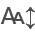

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

# Analyze finko data

## read in data

In [3]:
## read in the analyzed table ##

### change this according to the filepath on your system ###
filename = 'example-files/example-file-booking-lines.csv'
####

# read the data in and save in pandas dataframe #
finko_data = pd.read_csv(filename, delimiter=',', usecols=(3, 6, 7, 8, 9, 10), skiprows=0)
finko_data[:10]
finko_data['EUR'] = finko_data['EUR'].astype(float)

In [4]:
finko_data

verantw. Kostenstelle übergreifend  \
0                               XXXXXX   
1                               XXXXXX   
2                               XXXXXX   
3                               XXXXXX   
4                               XXXXXX   
..                                 ...   
134                             XXXXXX   
135                             XXXXXX   
136                             XXXXXX   
137                             XXXXXX   
138                             XXXXXX   

                                           Segmenttext     EUR  \
0    description text of the purchase used for clas...   81.20   
1    description text of the purchase used for clas...   81.49   
2    description text of the purchase used for clas...   81.55   
3    description text of the purchase used for clas...   81.63   
4    description text of the purchase used for clas...   81.84   
..                                                 ...     ...   
134  description text of the purchase used for clas...  101.05   
135  description text of the purchase used for clas...  101.06   
136  description text of the purchase used for clas...  101.28   
137  description text of the purchase used for clas...  101.30   
138  description text of the purchase used for clas...  101.52   

    Main Product Category 2nd level Product Category  Notes  
0           lab chemicals                    dry ice    NaN  
1           lab chemicals                    dry ice    NaN  
2           lab chemicals     solid/liquid chemicals    NaN  
3           lab chemicals     solid/liquid chemicals    NaN  
4         lab consumables                    plastic    NaN  
..                    ...                        ...    ...  
134       lab consumables         ? unknown material    NaN  
135       lab consumables                      metal    NaN  
136         life sciences              nucleic acids    NaN  
137         lab chemicals                      water    NaN  
138         life sciences              nucleic acids    NaN  

[139 rows x 6 columns]

In [5]:
## make sure your emission factors and the booking lines are either both with or without taxes
### we have to convert our booking lines to remove the taxes (because the emission factors are without)

In [6]:
finko_data['EUR'] = finko_data['EUR']/1.2

## define categories

In [7]:
## define the categories by hand ##

main_catagories = ['lab consumables', 'lab chemicals', 'life sciences', 'kits', 'services', 'furniture', 'office consumables', 'lab equipment']

sub_categories = {
    'lab consumables' : 
            ['Plastic', 'Glass', 'Gloves', 'Tissue Paper', 'wood', 'metal', 'rubber', 'cardboard', 'sand/quarz'],
    'lab chemicals' : 
            ['Liquid nitrogen', 'Solvents', 'antibiotics', 'gases', 'media', 'solid/liquid chemicals', 'detergents', 'dry ice'], 
    'life sciences' : 
            ['Enzymes/proteins', 'Antibodies', 'Nucleic Acids', 'Serum for cell culture', 'Plant material', 'medications', 'animals'],
    'kits' : 
            ['kits'],
    'services' : 
            [ '"prepaid sequencing labels"'],
    'furniture' : 
            ['furniture'],
    'office consumables' : 
            ['office consumables'],
    'lab equipment' :
            ['lab equipment']
}

In [8]:
## you can also use parts of data here to test out the code ##

df = finko_data#[:100]


## fill all the nan entries in catagory with a string ? to make it better parseable 
df['Main Product Category'] = df['Main Product Category'].fillna('?')

## for the value fill nan with 0
df['EUR'] = df['EUR'].fillna(0)
df = df.fillna("?")

## define analyzing functions ##

In [9]:
def get_idx(df, product_category, col_name):
    """
    Function to get all indexes where the the entry in the
    column 'col_name' of a dataframe is equal to a specific
    product category.

    Args:
        df (DataFrame)            :    pandas dataframe of the categoriezed entries
        product_category (string) :    the category you want the indices of 
        col_name (string)         :    the name of the column where you look for the category
    Returns:
        idx (list)                :    a list of the indices of the entries in this column
    """
    idx = []
    for i in range(len(df)):
        # check in all entries if the category is more or less the content of the column
        #print(df[col_name][i])
        #print(df[col_name][i], product_category)
        if df[col_name][i].strip().casefold() == product_category.casefold():
            idx.append(i)
        continue
        
    return idx

def analyze_df(df, product_categories, col_name):
    """
    Function to analyze a dataframe and get back the money
    spent on the main catgories and save it in a new
    dataframe.

    Args:
        df (DataFrame)               :    dataframe of the catgorized entries
        product_categories (list)    :    a list of the main categories to be extracted
        col_name (string)            :    the name of the column to search for the categories
    Returns:
        cost_df (DataFrame)          :    The dataframe with the saved costs
        group_idxs (list)            :    list with all of the indices in sublists for the categories
    """

    ## create a dataframe to store the values in ##
    cost_df = pd.DataFrame(data={'value' : np.zeros(len(product_categories)), 'percentage' : np.zeros(len(product_categories))}, index=product_categories)
    cost_df.loc['unknown'] = 'unknown'

    ## analyzte the data ##
    all_idxs = []
    group_idxs = {}
    costs = []
    
    for cat in product_categories:
        # get all of the indices of entries in the column with the product category
        idxs = get_idx(df, cat, col_name)
        # add these to the lists
        all_idxs += idxs
        group_idxs[cat] = idxs
        # calculate the value of all of those by summing them
        cost = sum(df['EUR'][idxs])
        # set the according entry of the new dataframe with this value
        cost_df.loc[cat,'value'] = cost

    # the the indices of all values that could not be identified by subtracting
        # the elements found from all indices
    missing_elements = list(set(range(len(df))) - set(np.sort(all_idxs)))

    # set those as last element in the list of all lists of indices
    group_idxs["unknown"] = missing_elements

    # get a number of the unknown costs and add it to the dataframe
    cost_unknown = sum(df['EUR'][missing_elements])
    cost_df.loc['unknown','value'] = cost_unknown

    # get the percentages
    if sum(cost_df['value']) > 0:
        cost_df['percentage'] = cost_df['value']/sum(cost_df['value']) * 100

    ## a few sanity checks ##
    if len(all_idxs + missing_elements) != len(set(all_idxs + missing_elements)):
        newlist = [] # empty list to hold unique elements from the list
        duplist = [] # empty list to hold the duplicate elements from the list
        for i in all_idxs + missing_elements:
            if i not in newlist:
                newlist.append(i)
            else:
                duplist.append(i) # this method catches the first duplicate entries, and appends them to the list
        print(duplist)
        raise ValueError('Some of the indices are not unique')
    
    if len(all_idxs + missing_elements) != len(df):
        raise ValueError('Not all indices accounted for.')

    
    return cost_df, group_idxs

## get values ##

### main categories ###

In [10]:
main_cat_df, group_idxs = analyze_df(df, main_catagories, "Main Product Category")

In [11]:
main_cat_df

value percentage
lab consumables     3746.516667  35.874463
lab chemicals       3108.991667  29.769895
life sciences          2841.825  27.211662
kits                 364.091667    3.48633
services                  240.9   2.306718
furniture                     0        0.0
office consumables         69.0   0.660704
lab equipment                 0        0.0
unknown               72.083333   0.690228

In [13]:
## you can also access specific groups here

In [12]:
df.iloc[group_idxs['unknown']]

verantw. Kostenstelle übergreifend  \
52                             XXXXXX   

                                          Segmenttext        EUR  \
52  description text of the purchase used for clas...  72.083333   

   Main Product Category 2nd level Product Category Notes  
52                     ?                          ?     ?

### sub categories ###

In [15]:
sub_dfs = {}
idxs_dict = {}
for i, key in enumerate(sub_categories.keys()):

    # only make sub dataframes for categories with at least two sub categories #
    if len(sub_categories[key]) < 2:
        continue

    # ignore empty categories #
    if main_cat_df.loc[key, "value"] == 0: 
        continue
        
    else:
        ## choose all of the data attributed to this category above ##
        sub_data = df.loc[group_idxs[key]].reset_index() 
    
        # use the function defined above to select the entries in the new dataframe according to their second level and again write it in a new dataframe
        sub_df, _idxs = analyze_df(sub_data, sub_categories[key], col_name='2nd level Product Category')
        sub_dfs[key] = sub_df
        idxs_dict[key] = _idxs

In [16]:
def access_sub_df(main_cat, sub_cat, main_group_idx, sub_group_idx, dataframe):

    sub_df = dataframe.iloc[main_group_idx[main_cat]].reset_index().iloc[sub_group_idx[main_cat][sub_cat]]

    return sub_df

In [21]:
## you can also here access the data for specific categories
access_sub_df("life sciences", "Antibodies", group_idxs, idxs_dict, df)

index verantw. Kostenstelle übergreifend  \
19     67                             XXXXXX   

                                          Segmenttext        EUR  \
19  description text of the purchase used for clas...  73.958333   

   Main Product Category 2nd level Product Category Notes  
19         life sciences                 antibodies     ?

In [22]:
sub_dfs['life sciences']

value percentage
Enzymes/proteins        1419.266667  49.942085
Antibodies                73.958333   2.602494
Nucleic Acids                1063.3  37.416097
Serum for cell culture            0        0.0
Plant material                215.1    7.56908
medications                       0        0.0
animals                        70.2   2.470244
unknown                           0        0.0

In [23]:
sub_dfs['lab consumables']

value percentage
Plastic       2294.066667  61.231989
Glass          507.741667  13.552366
Gloves            158.225   4.223256
Tissue Paper            0        0.0
wood            72.183333   1.926679
metal               398.7  10.641885
rubber                  0        0.0
cardboard               0        0.0
sand/quarz              0        0.0
unknown             315.6   8.423825

In [24]:
sub_dfs['lab chemicals']

value percentage
Liquid nitrogen                   0        0.0
Solvents                 460.183333  14.801691
antibiotics                       0        0.0
gases                          71.3   2.293348
media                    236.858333   7.618494
solid/liquid chemicals  1666.341667  53.597495
detergents                   74.875   2.408337
dry ice                     205.575   6.612272
unknown                  393.858333  12.668362

## make a plot of the money spent

In [25]:
import matplotlib as mpl
cmap = mpl.colormaps['Set3']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 9))

/tmp/ipykernel_12173/2608324489.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  main_cat_df.plot.pie(y = 'value', labeldistance=None, colors=colors, title='percentage of money spent on main product groups', ax=axs['Left']);
/tmp/ipykernel_12173/2608324489.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


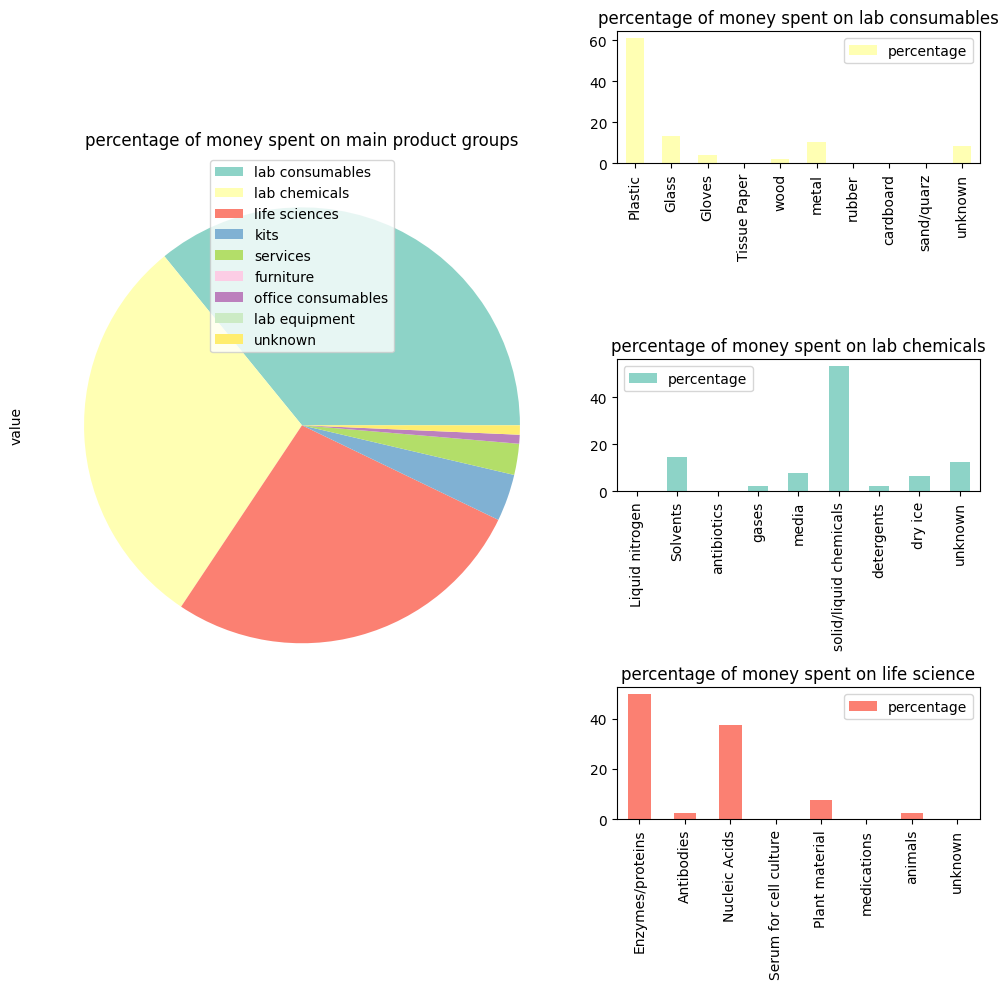

In [27]:
fig = plt.figure(constrained_layout=True, figsize=(10,6))
axs = fig.subplot_mosaic([['Left', 'TopRight'],['Left', 'MiddleRight'], ['Left', 'BottomRight']],
                          gridspec_kw={'width_ratios':[1.5, 1]})
axs['Left'].set_title('Plot on Left')
axs['TopRight'].set_title('Plot Top Right')
axs['MiddleRight'].set_title('Plot Middle Right')
axs['BottomRight'].set_title('Plot Bottom Right')

main_cat_df.plot.pie(y = 'value', labeldistance=None, colors=colors, title='percentage of money spent on main product groups', ax=axs['Left']);

sub_dfs['lab consumables'].plot.bar(y = 'percentage', figsize=(10,10), title='percentage of money spent on lab consumables', color=colors[1], ax=axs['TopRight']);#, colors=colors, labeldistance=None, );
sub_dfs['lab chemicals'].plot.bar(y = 'percentage', figsize=(10,10), title='percentage of money spent on lab chemicals', color=colors[0], ax=axs['MiddleRight']);#, colors=colors, labeldistance=None, );
sub_dfs['life sciences'].plot.bar(y = 'percentage', figsize=(10,10), title='percentage of money spent on life science', color=colors[2], ax=axs['BottomRight']);#, colors=colors, labeldistance=None, );

plt.tight_layout()

#plt.savefig('savepath.pdf', bbox_inches='tight', dpi=200)



# Emission factors

In [33]:
## read in emission factor file ##

filepath = 'example-files/example-file-emission-factors.csv'

efs = pd.read_csv(filepath, delimiter=',', usecols=(0,1,2,4,5,6)).dropna(axis=0, how='all')
efs

group  EF group (kgCO2/€)  error group  \
0      lab consumables                0.57         0.80   
1      lab consumables                0.57         0.80   
2      lab consumables                0.57         0.80   
3      lab consumables                0.57         0.80   
4      lab consumables                0.57         0.80   
5      lab consumables                0.57         0.80   
6      lab consumables                0.57         0.80   
7      lab consumables                0.57         0.80   
8      lab consumables                0.57         0.80   
9        lab chemicals                0.47         0.77   
10       lab chemicals                0.47         0.77   
11       lab chemicals                0.47         0.77   
12       lab chemicals                0.47         0.77   
13       lab chemicals                0.47         0.77   
14       lab chemicals                0.47         0.77   
15       lab chemicals                0.47         0.77   
16       lab chemicals                0.47         0.77   
17        life science                0.65         0.90   
18        life science                0.65         0.90   
19        life science                0.65         0.90   
20        life science                0.65         0.90   
21        life science                0.65         0.90   
22        life science                0.65         0.90   
23        life science                0.65         0.90   
24                kits                0.38         0.62   
25            services                0.07         0.06   
26           furniture                0.59         0.24   
27  office consumables                0.50         0.12   
28       lab equipment                0.28         0.32   

                     subgroup  EF subgroup (kgCO2/€)  error subgroup  
0                     Plastic                   0.56            0.59  
1                       Glass                   0.53            0.80  
2                      Gloves                   0.52            0.42  
3                Tissue Paper                   0.70            0.39  
4                        wood                   0.48            0.08  
5                       metal                   0.48            0.15  
6                      rubber                   1.00            0.20  
7                   cardboard                   0.67            0.20  
8                  sand/quarz                   0.61            0.27  
9             Liquid nitrogen                   0.42            0.33  
10                   Solvents                   0.59            0.41  
11                antibiotics                   0.15            0.12  
12                      gases                   0.43            0.60  
13                      media                   0.16            0.12  
14     solid/liquid chemicals                   0.45            0.36  
15                 detergents                   0.50             NaN  
16                    dry ice                   0.96            0.77  
17           Enzymes/proteins                   0.19            0.21  
18                 Antibodies                   0.14            0.11  
19              Nucleic Acids                   0.32            0.20  
20     Serum for cell culture                   0.16            0.12  
21             Plant material                   1.70            0.60  
22                medications                   0.36            0.19  
23                    animals                   0.67            0.90  
24                       kits                   0.38            0.62  
25  prepaid sequencing labels                   0.07            0.06  
26                  furniture                   0.59            0.24  
27         office consumables                   0.50            0.12  
28              lab equipment                   0.28            0.32

In [34]:
def get_emissions_sub(cost_df, group, efs):
    ## get the emission factors for this group ##
    sub_df = efs.loc[efs["group"] == group].reset_index(drop=True)
    #print(sub_df)

    ## get the emission factors for the subgroups ##
    for subgroup in sub_df['subgroup']:
        EF = sub_df.loc[sub_df['subgroup']==subgroup]['EF subgroup (kgCO2/€)'].item()
        SD = sub_df.loc[sub_df['subgroup']==subgroup]['error subgroup'].item()

        cost_df.loc[subgroup, 'emission'] = EF * cost_df.loc[subgroup]['value']
        cost_df.loc[subgroup, 'uncertainty'] = SD * cost_df.loc[subgroup]['value']

    cost_df.loc["unknown", "emission"] = sub_df["EF group (kgCO2/€)"][0]*cost_df.loc["unknown"]['value']
    cost_df.loc["unknown", "uncertainty"] = sub_df["error group"][0]*cost_df.loc["unknown"]['value']
    
    if sum(cost_df['emission']) > 0:
        cost_df['percentage emission'] = cost_df['emission']/sum(cost_df['emission']) * 100


    return cost_df
    


### apply to the three big sectors ###

In [35]:
life_science_df = sub_dfs["life sciences"]
life_science_df = get_emissions_sub(life_science_df, "life science", efs)
life_science_df


value percentage    emission  uncertainty  \
Enzymes/proteins        1419.266667  49.942085  269.660667   298.046000   
Antibodies                73.958333   2.602494   10.354167     8.135417   
Nucleic Acids                1063.3  37.416097  340.256000   212.660000   
Serum for cell culture            0        0.0    0.000000     0.000000   
Plant material                215.1    7.56908  365.670000   129.060000   
medications                       0        0.0    0.000000     0.000000   
animals                        70.2   2.470244   47.034000    63.180000   
unknown                           0        0.0    0.000000     0.000000   

                        percentage emission  
Enzymes/proteins                  26.105250  
Antibodies                         1.002364  
Nucleic Acids                     32.939428  
Serum for cell culture             0.000000  
Plant material                    35.399701  
medications                        0.000000  
animals                            4.553257  
unknown                            0.000000

In [36]:
lab_consumables_df = sub_dfs["lab consumables"]
lab_consumables_df = get_emissions_sub(lab_consumables_df, "lab consumables", efs)
lab_consumables_df

value percentage     emission  uncertainty  \
Plastic       2294.066667  61.231989  1284.677333  1353.499333   
Glass          507.741667  13.552366   269.103083   406.193333   
Gloves            158.225   4.223256    82.277000    66.454500   
Tissue Paper            0        0.0     0.000000     0.000000   
wood            72.183333   1.926679    34.648000     5.774667   
metal               398.7  10.641885   191.376000    59.805000   
rubber                  0        0.0     0.000000     0.000000   
cardboard               0        0.0     0.000000     0.000000   
sand/quarz              0        0.0     0.000000     0.000000   
unknown             315.6   8.423825   179.892000   252.480000   

              percentage emission  
Plastic                 62.913519  
Glass                   13.178579  
Gloves                   4.029288  
Tissue Paper             0.000000  
wood                     1.696790  
metal                    9.372110  
rubber                   0.000000  
cardboard                0.000000  
sand/quarz               0.000000  
unknown                  8.809713

In [37]:
lab_chemicals_df = sub_dfs["lab chemicals"]
lab_chemicals_df = get_emissions_sub(lab_chemicals_df, "lab chemicals", efs)
lab_chemicals_df

value percentage    emission  uncertainty  \
Liquid nitrogen                   0        0.0    0.000000     0.000000   
Solvents                 460.183333  14.801691  271.508167   188.675167   
antibiotics                       0        0.0    0.000000     0.000000   
gases                          71.3   2.293348   30.659000    42.780000   
media                    236.858333   7.618494   37.897333    28.423000   
solid/liquid chemicals  1666.341667  53.597495  749.853750   599.883000   
detergents                   74.875   2.408337   37.437500          NaN   
dry ice                     205.575   6.612272  197.352000   158.292750   
unknown                  393.858333  12.668362  185.113417   303.270917   

                        percentage emission  
Liquid nitrogen                    0.000000  
Solvents                          17.982803  
antibiotics                        0.000000  
gases                              2.030638  
media                              2.510054  
solid/liquid chemicals            49.665071  
detergents                         2.479598  
dry ice                           13.071217  
unknown                           12.260619

## look at main categories ##

In [38]:
## add the in more detail analyzed sectors ##

main_cat_df.loc["life sciences", "emission"] = sum(life_science_df["emission"])
main_cat_df.loc["life sciences", "uncertainty"] = sum(life_science_df["uncertainty"])

main_cat_df.loc["lab chemicals", "emission"] = sum(lab_chemicals_df["emission"])
main_cat_df.loc["lab chemicals", "uncertainty"] = np.nansum(lab_chemicals_df["uncertainty"])

main_cat_df.loc["lab consumables", "emission"] = sum(lab_consumables_df["emission"])
main_cat_df.loc["lab consumables", "uncertainty"] = sum(lab_consumables_df["uncertainty"])

In [39]:
main_cat_df

value percentage     emission  uncertainty
lab consumables     3746.516667  35.874463  2041.973417  2144.206833
lab chemicals       3108.991667  29.769895  1509.821167  1321.324833
life sciences          2841.825  27.211662  1032.974833   711.081417
kits                 364.091667    3.48633          NaN          NaN
services                  240.9   2.306718          NaN          NaN
furniture                     0        0.0          NaN          NaN
office consumables         69.0   0.660704          NaN          NaN
lab equipment                 0        0.0          NaN          NaN
unknown               72.083333   0.690228          NaN          NaN

In [40]:
## look at the other sectors ##

### extract the main emission factors 

In [41]:
names_main = set(efs["group"])

main_efs_dict = {}
main_sts_dict = {}
for i, name in enumerate(names_main):
    sub_df = efs[efs["group"]==name].reset_index(drop=True)
    ef = float(sub_df["EF group (kgCO2/€)"][0])
    sd = float(sub_df["error group"][0])
    
    main_efs_dict[name] = ef
    main_sts_dict[name] = sd


In [43]:
for key in main_efs_dict:
    if key in ['life science', 'lab consumables', 'lab chemicals']:
        continue
    else:
        main_cat_df.loc[key, "emission"] = main_efs_dict[key] * main_cat_df.loc[key, 'value']
        main_cat_df.loc[key, "uncertainty"] = main_sts_dict[key] * main_cat_df.loc[key, 'value']

main_cat_df['percentage emission'] = main_cat_df['emission']/np.nansum(main_cat_df['emission']) * 100

In [44]:
main_cat_df.sort_values(by="percentage emission", ascending=False)

value percentage     emission  uncertainty  \
lab consumables     3746.516667  35.874463  2041.973417  2144.206833   
lab chemicals       3108.991667  29.769895  1509.821167  1321.324833   
life sciences          2841.825  27.211662  1032.974833   711.081417   
kits                 364.091667    3.48633   138.354833   225.736833   
office consumables         69.0   0.660704    34.500000     8.280000   
services                  240.9   2.306718    16.863000    14.454000   
furniture                     0        0.0     0.000000     0.000000   
lab equipment                 0        0.0     0.000000     0.000000   
unknown               72.083333   0.690228          NaN          NaN   

                    percentage emission  
lab consumables               42.768434  
lab chemicals                 31.622687  
life sciences                 21.635304  
kits                           2.897795  
office consumables             0.722591  
services                       0.353190  
furniture                      0.000000  
lab equipment                  0.000000  
unknown                             NaN

## make plots

In [54]:
def sub_plot_emission(df, title, save=False):
    colors = cmap(np.linspace(0, 1, len(df)))
    fig = plt.figure(constrained_layout=True, figsize=(10,8))
    axs = fig.subplot_mosaic([['Left', 'RightUp'], ['Left', 'RightLow']],
                              gridspec_kw={'width_ratios':[2, 1]})
    axs['Left'].set_title('Plot on Left')
    axs['RightUp'].set_title('Right')
    
    already_analyzed = df['value'].sum()/(df['value'].sum())*100
    
    sum_of_emissions = df['emission'].sum()
    
    def val(num):
        if num < 4:
            return ''
        else:
            return np.round(num/100*sum_of_emissions*1e-3, 2)
    
    
    df.plot.pie(y = 'emission', labeldistance=None, colors=colors, title='CO2 equivalent in tons', ax=axs['Left'], autopct=val);
    df.plot.barh(y = 'emission', title='CO2 equivalent in kg', color=colors, ax=axs['RightUp'], xerr=df['uncertainty'], capsize=4);#, colors=colors, labeldistance=None, );
    
    df.plot.barh(y = 'value', title='money spent \wo taxes', color='k', ax=axs['RightLow']);#, colors=colors, labeldistance=None, );
    
    #axs['RightUp'].errorbar(x= yerr=cost_df_ls_w_efs_relevant['uncertainty'])
    #s = f"\n\nSpendings already converted to emissions: {round(already_analyzed)} %"
    
    #axs["Left"].text(s=s, x=-.8, y=-1.5)
    
    plt.suptitle(title)
    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=200)
    
    plt.show()


/tmp/ipykernel_12173/2132320675.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


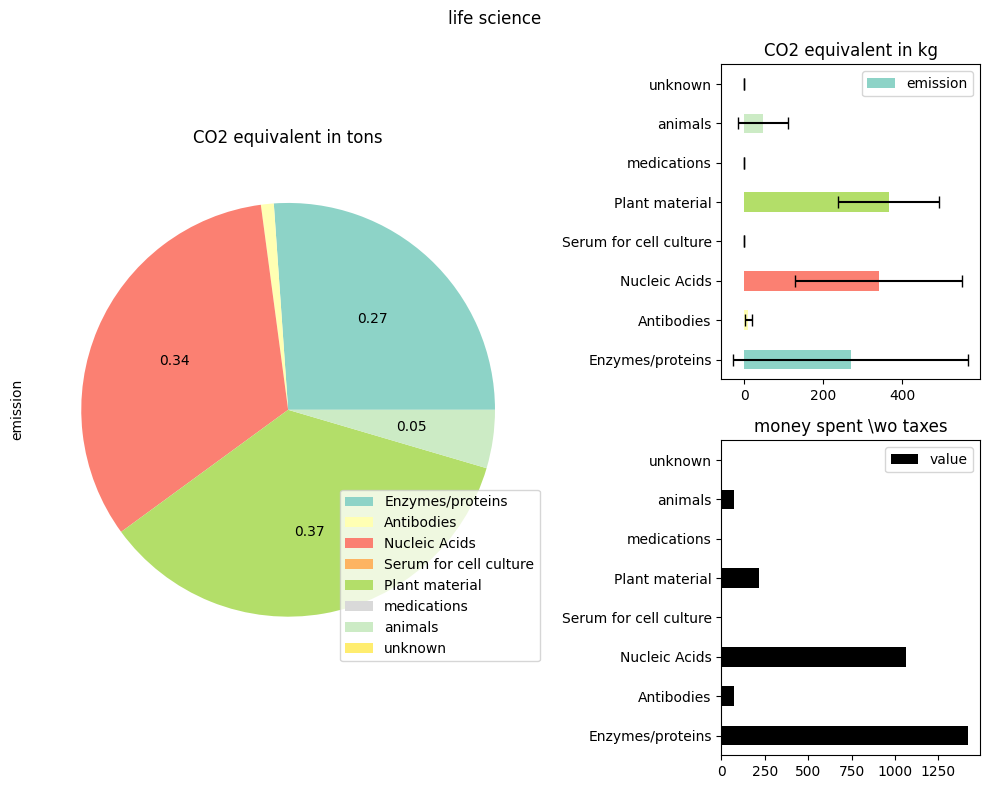

In [55]:
sub_plot_emission(life_science_df, title="life science")#, save="savepath.pdf")

/tmp/ipykernel_12173/2132320675.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


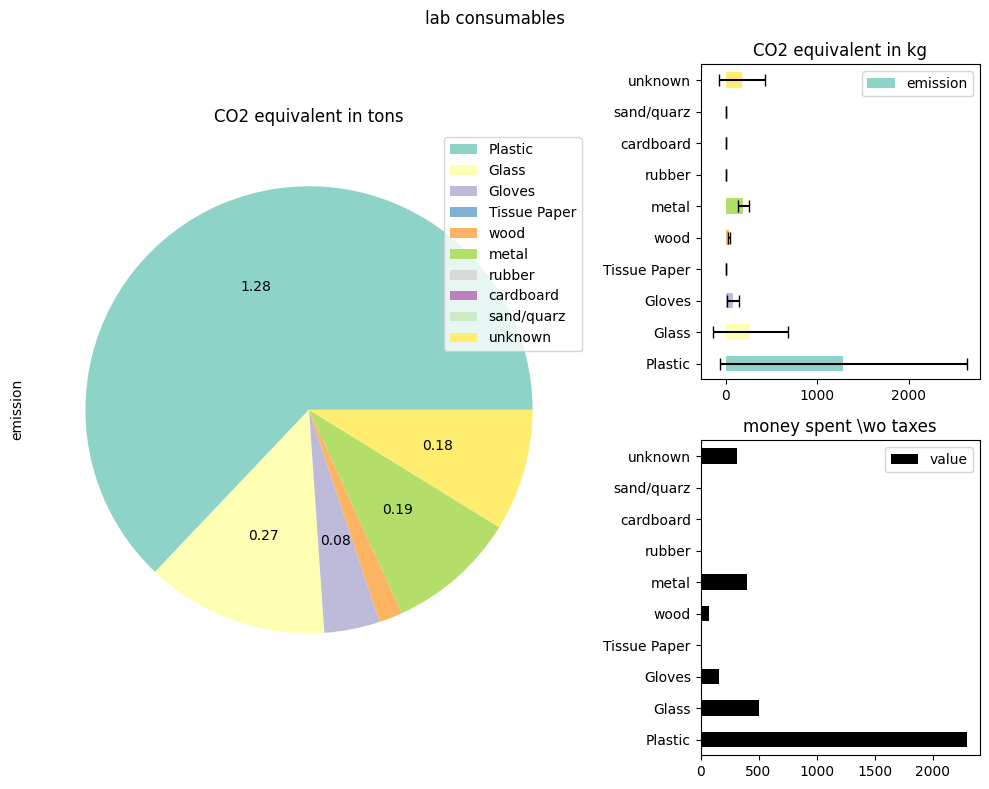

In [56]:
sub_plot_emission(lab_consumables_df, title="lab consumables")#, save="savepath.pdf")

/tmp/ipykernel_12173/2132320675.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


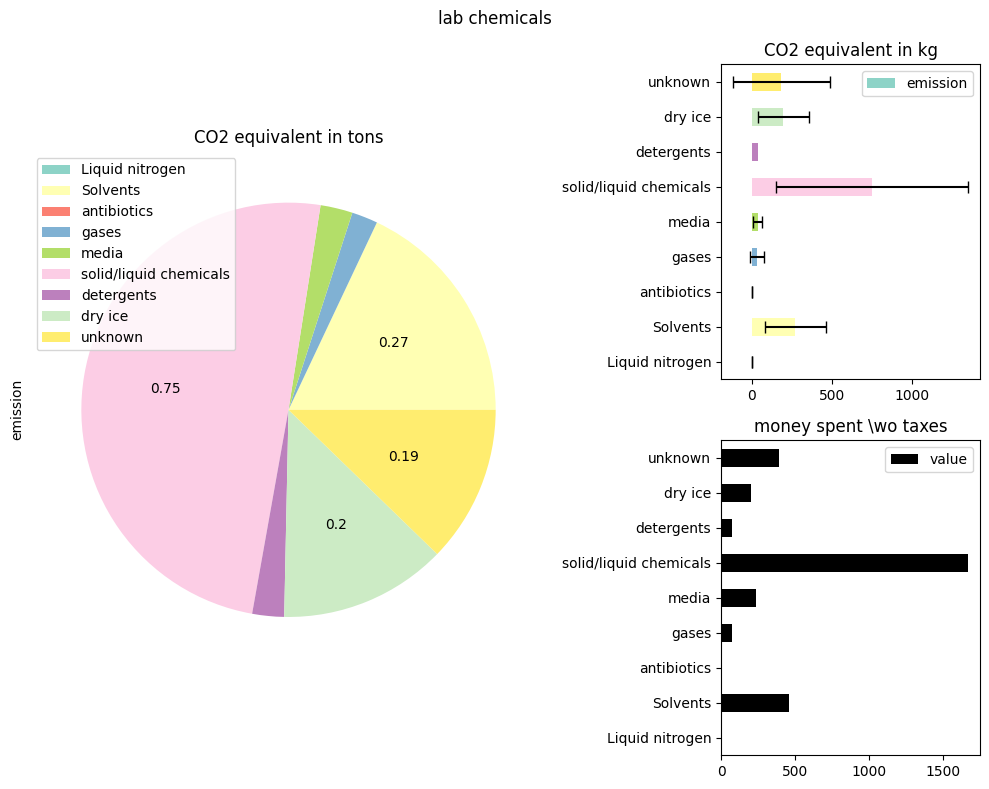

In [57]:
sub_plot_emission(lab_chemicals_df, title="lab chemicals")#, save="savepath.pdf")

/tmp/ipykernel_12173/2132320675.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


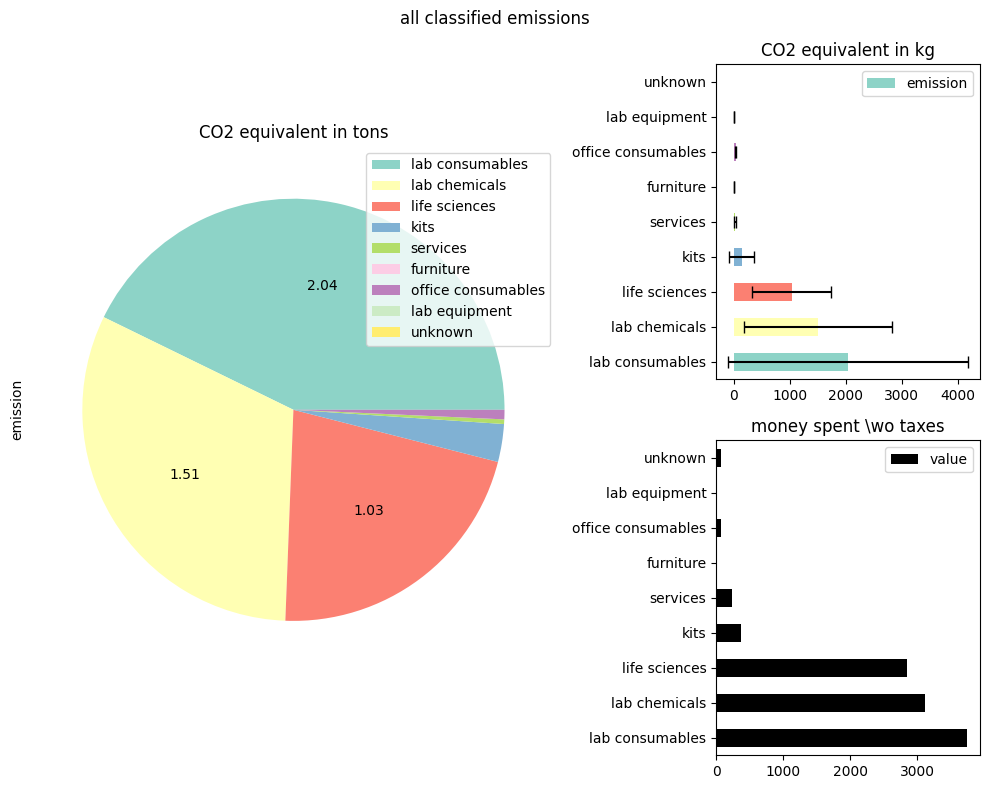

In [59]:
sub_plot_emission(main_cat_df, title='all classified emissions')

## Save the relevant tables 

In [60]:
main_cat_df

value percentage     emission  uncertainty  \
lab consumables     3746.516667  35.874463  2041.973417  2144.206833   
lab chemicals       3108.991667  29.769895  1509.821167  1321.324833   
life sciences          2841.825  27.211662  1032.974833   711.081417   
kits                 364.091667    3.48633   138.354833   225.736833   
services                  240.9   2.306718    16.863000    14.454000   
furniture                     0        0.0     0.000000     0.000000   
office consumables         69.0   0.660704    34.500000     8.280000   
lab equipment                 0        0.0     0.000000     0.000000   
unknown               72.083333   0.690228          NaN          NaN   

                    percentage emission  
lab consumables               42.768434  
lab chemicals                 31.622687  
life sciences                 21.635304  
kits                           2.897795  
services                       0.353190  
furniture                      0.000000  
office consumables             0.722591  
lab equipment                  0.000000  
unknown                             NaN

In [159]:
#main_cat_df.to_csv(<savepath>.csv)

In [61]:
life_science_df

value percentage    emission  uncertainty  \
Enzymes/proteins        1419.266667  49.942085  269.660667   298.046000   
Antibodies                73.958333   2.602494   10.354167     8.135417   
Nucleic Acids                1063.3  37.416097  340.256000   212.660000   
Serum for cell culture            0        0.0    0.000000     0.000000   
Plant material                215.1    7.56908  365.670000   129.060000   
medications                       0        0.0    0.000000     0.000000   
animals                        70.2   2.470244   47.034000    63.180000   
unknown                           0        0.0    0.000000     0.000000   

                        percentage emission  
Enzymes/proteins                  26.105250  
Antibodies                         1.002364  
Nucleic Acids                     32.939428  
Serum for cell culture             0.000000  
Plant material                    35.399701  
medications                        0.000000  
animals                            4.553257  
unknown                            0.000000

In [62]:
#life_science_df.to_csv(<savepath>.csv)

In [63]:
lab_consumables_df

value percentage     emission  uncertainty  \
Plastic       2294.066667  61.231989  1284.677333  1353.499333   
Glass          507.741667  13.552366   269.103083   406.193333   
Gloves            158.225   4.223256    82.277000    66.454500   
Tissue Paper            0        0.0     0.000000     0.000000   
wood            72.183333   1.926679    34.648000     5.774667   
metal               398.7  10.641885   191.376000    59.805000   
rubber                  0        0.0     0.000000     0.000000   
cardboard               0        0.0     0.000000     0.000000   
sand/quarz              0        0.0     0.000000     0.000000   
unknown             315.6   8.423825   179.892000   252.480000   

              percentage emission  
Plastic                 62.913519  
Glass                   13.178579  
Gloves                   4.029288  
Tissue Paper             0.000000  
wood                     1.696790  
metal                    9.372110  
rubber                   0.000000  
cardboard                0.000000  
sand/quarz               0.000000  
unknown                  8.809713

In [64]:
#lab_consumables_df.to_csv(<savepath>.csv)

In [65]:
lab_chemicals_df

value percentage    emission  uncertainty  \
Liquid nitrogen                   0        0.0    0.000000     0.000000   
Solvents                 460.183333  14.801691  271.508167   188.675167   
antibiotics                       0        0.0    0.000000     0.000000   
gases                          71.3   2.293348   30.659000    42.780000   
media                    236.858333   7.618494   37.897333    28.423000   
solid/liquid chemicals  1666.341667  53.597495  749.853750   599.883000   
detergents                   74.875   2.408337   37.437500          NaN   
dry ice                     205.575   6.612272  197.352000   158.292750   
unknown                  393.858333  12.668362  185.113417   303.270917   

                        percentage emission  
Liquid nitrogen                    0.000000  
Solvents                          17.982803  
antibiotics                        0.000000  
gases                              2.030638  
media                              2.510054  
solid/liquid chemicals            49.665071  
detergents                         2.479598  
dry ice                           13.071217  
unknown                           12.260619

In [66]:
#lab_chemicals_df.to_csv(<savepath>.csv)

## checks

In [67]:
np.nansum(main_cat_df["value"])

10443.408333333333

In [68]:
np.nansum(df["EUR"])

np.float64(10443.408333333333)

In [69]:
## money checks out ##